# 05 - Testing metrics

In [83]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt


import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import ambient_light_epilepsy.lux_metrics as lm
import time


def get_sampling_interval_minutes(df):
    df = df.sort_values("timestamp")
    delta = (df["timestamp"].iloc[1] - df["timestamp"].iloc[0]).total_seconds()
    return delta / 60

## Load a data file

In [47]:
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[100]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()

Time taken to load parquet with pyarrow: 0.882 s


,timestamp,mean_lux
0,2000-01-06 12:32:30+00:00,46.650000
1,2000-01-06 12:37:30+00:00,14.866667
2,2000-01-06 12:42:30+00:00,8.800000
3,2000-01-06 12:47:30+00:00,0.316667
4,2000-01-06 12:52:30+00:00,0.606667
...,...,...
2301,2000-01-14 12:17:30+00:00,0.000000
2302,2000-01-14 12:22:30+00:00,0.000000
2303,2000-01-14 12:27:30+00:00,0.000000
2304,2000-01-14 12:32:30+00:00,0.000000


## Daytime and nightitme definitions

In [48]:
def compute_mean_daytime_lux(df, day_start=7, day_end=19):
    """
    Computes mean daytime lux.

    Parameters
    ----------
    df : pandas DataFrame
        Must contain columns:
            - 'timestamp' (datetime)
            - 'mean_lux'
    day_start : int
        Start hour (inclusive)
    day_end : int
        End hour (exclusive)

    Returns
    -------
    float
        Mean daytime lux
    """

    hours = df["timestamp"].dt.hour

    mask = (hours >= day_start) & (hours < day_end)

    if mask.sum() == 0:
        return np.nan

    return df.loc[mask, "mean_lux"]#.mean()


def compute_mean_nighttime_lux(df, night_start=22, night_end=5):
    """
    Computes mean nighttime lux.

    Handles windows that cross midnight.

    Parameters
    ----------
    df : pandas DataFrame
        Must contain columns:
            - 'timestamp' (datetime)
            - 'mean_lux'
    night_start : int
        Start hour (inclusive)
    night_end : int
        End hour (exclusive)

    Returns
    -------
    float
        Mean nighttime lux
    """

    hours = df["timestamp"].dt.hour

    if night_start < night_end:
        # Does NOT cross midnight
        mask = (hours >= night_start) & (hours < night_end)
    else:
        # Crosses midnight (e.g., 22–05)
        mask = (hours >= night_start) | (hours < night_end)

    if mask.sum() == 0:
        return np.nan

    return df.loc[mask, "mean_lux"]#.mean()

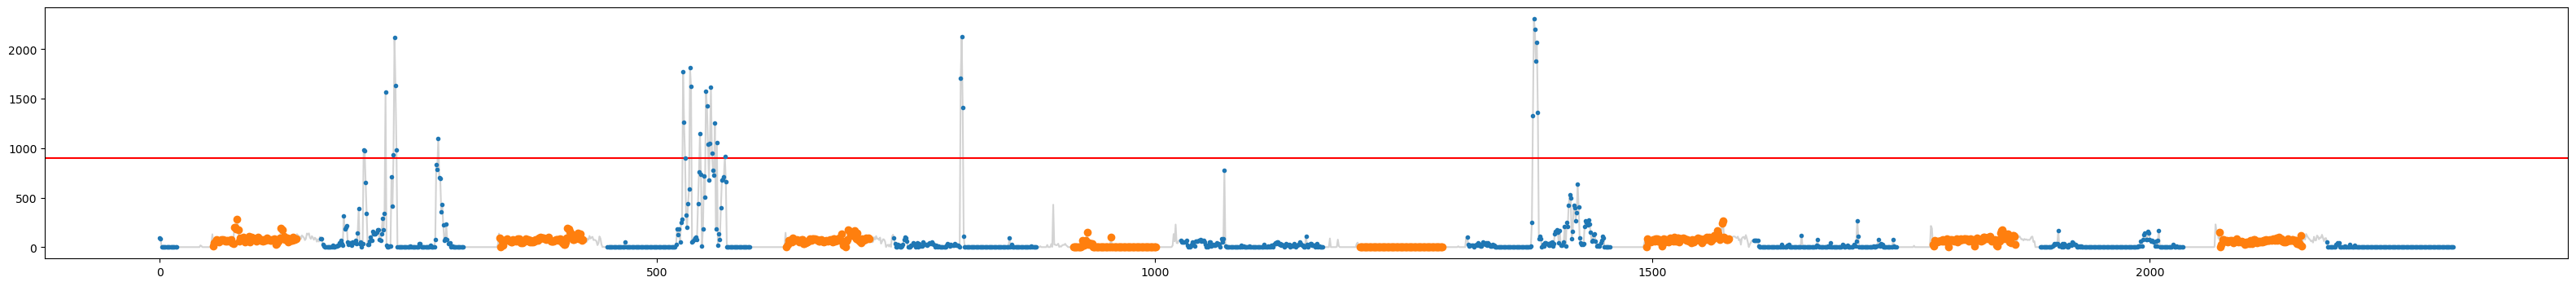

In [104]:
# Load the file
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[4]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()


# run analysis and plot
fig, ax = plt.subplots(figsize=(40,4))

ax.plot(df['mean_lux'], color='lightgrey')
ax.axhline(900, color='r')

day = compute_mean_daytime_lux(df)
night = compute_mean_nighttime_lux(df)
ax.plot(day, '.')
ax.plot(night, 'o')

## Time above threshold

In [77]:
import numpy as np
import pandas as pd

def get_sampling_interval_minutes(df):
    df = df.sort_values("timestamp")
    delta = (df["timestamp"].iloc[1] - df["timestamp"].iloc[0]).total_seconds()
    return delta / 60


def time_above_threshold_normalized(df, threshold=1000):
    df = df.copy()
    df = df.sort_values("timestamp")
    
    # Detect sampling rate
    epoch_minutes = get_sampling_interval_minutes(df)
    
    # Compute time above threshold
    epochs_above = (df["mean_lux"] > threshold).sum()
    
    # Convert to percentage of recording
    percent_above = epochs_above / len(df)
    
    # Convert to an average mins per day above threshold
    mins_per_day_above = percent_above * 60 * 24
        
    return mins_per_day_above



In [96]:
df = df.copy()
df = df.sort_values("timestamp")

# Detect sampling rate
epoch_minutes = get_sampling_interval_minutes(df)

# Compute time above threshold
epochs_above = (df["mean_lux"] > threshold).sum()

# Convert to percentage of recording
percent_above = epochs_above / len(df)

# Convert to an average mins per day above threshold
mins_per_day_above = percent_above * 60 * 24

In [97]:
mins_per_day_above

np.float64(19.35819601040763)

0.0


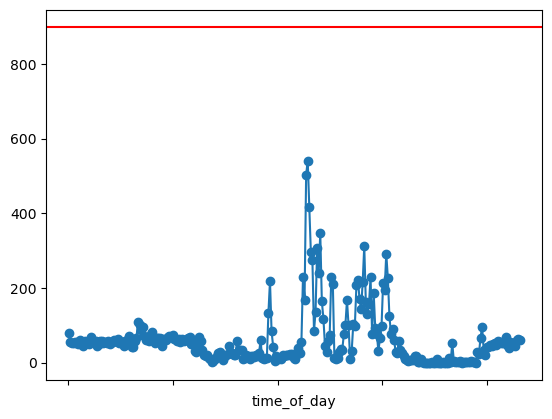

In [82]:
# Load the recording
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[4]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()


# Run analysis
threshold = 900
mins, percent = lm.time_above_threshold_normalized(df, threshold=threshold)
print(mins)

# Create time-of-day
df["time_of_day"] = df["timestamp"].dt.time

# Average across days to get 24h profile
mean_24h = df.groupby("time_of_day")["mean_lux"].mean()

fig, ax = plt.subplots()
mean_24h.plot(ax=ax, style='o-')
mean_24h[mean_24h>threshold].plot(ax=ax, style='o', color='r')
ax.axhline(threshold, color='r')

## Relative amplitude

In [72]:
def relative_amplitude(df):
    df = df.copy()
    df = df.sort_values("timestamp")
    
    epoch_minutes = lm.get_sampling_interval_minutes(df)
    
    # Average 24h profile
    df["time_of_day"] = df["timestamp"].dt.time
    mean_24h = df.groupby("time_of_day")["mean_lux"].mean()
    
    values = mean_24h.values
    
    samples_per_hour = int(60 / epoch_minutes)
    m10_window = 10 * samples_per_hour
    l5_window = 5 * samples_per_hour
    
    # Circular extension
    extended = np.concatenate([values, values])
    
    # Rolling means
    #m10 = np.max(pd.Series(extended).rolling(m10_window).mean())
    m10 = pd.Series(extended).rolling(m10_window).mean().max()
    l5 = pd.Series(extended).rolling(l5_window).mean().min()
    
    ra = (m10 - l5) / (m10 + l5)
    
    return m10, l5, ra


def relative_amplitude(df):

    df = df.copy()
    df = df.sort_values("timestamp")
    
    epoch_minutes = lm.get_sampling_interval_minutes(df)
    
    # Average 24h profile
    df["time_of_day"] = df["timestamp"].dt.time
    mean_24h = df.groupby("time_of_day")["mean_lux"].mean()
    
    values = mean_24h.values
    
    samples_per_hour = int(60 / epoch_minutes)
    m10_window = 10 * samples_per_hour
    l5_window = 5 * samples_per_hour
    
    # Circular extension
    extended = np.concatenate([values, values])
    
    # Rolling means
    m10_roll = pd.Series(extended).rolling(m10_window).mean()
    l5_roll = pd.Series(extended).rolling(l5_window).mean()
    
    m10 = m10_roll.max()
    l5 = l5_roll.min()
    
    ra = (m10 - l5) / (m10 + l5)
    
    # ---- M10 midpoint calculation ----
    
    m10_idx = m10_roll.idxmax()
    
    start_idx = m10_idx - m10_window + 1
    midpoint_idx = start_idx + m10_window // 2
    
    # wrap to 24h
    midpoint_idx = midpoint_idx % len(values)
    
    minutes_per_sample = epoch_minutes
    m10_midpoint_minutes = midpoint_idx * minutes_per_sample
    
    hours = int(m10_midpoint_minutes // 60)
    minutes = int(m10_midpoint_minutes % 60)
    
    m10_midpoint_time = pd.Timestamp(
        f"{hours:02d}:{minutes:02d}"
    ).time()
    
    return m10, l5, ra, m10_midpoint_minutes, m10_midpoint_time

In [73]:
pd.Series([1,2,3,10,4,5,6]).idxmax()

3

(np.float64(146.95212037037038),
 np.float64(0.0),
 np.float64(1.0),
 900.0,
 datetime.time(15, 0))

np.float64(142.77795370370367)

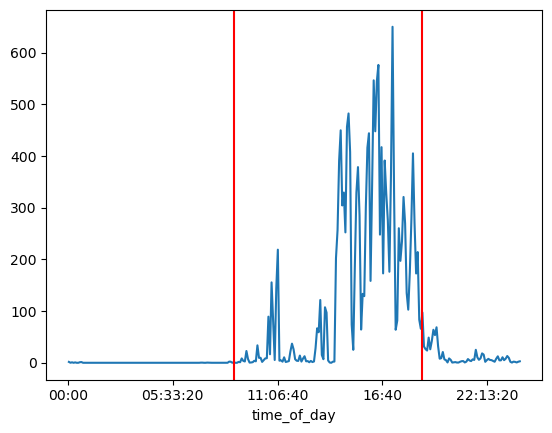

In [74]:
# Calculate relative amplitude, and m10, from data
display(relative_amplitude(df))

# Approximate the start and end of the m10 window
start = 105
h10 = start + 12*10

# Plot the daily pattern and approximate start and end times 
fig, ax = plt.subplots()
mean_24h.plot(ax=ax)
ax.axvline(mean_24h.index[start], color='r')
ax.axvline(mean_24h.index[h10], color='r')


# Print the mean of the m10 window, should align with function 
mean_24h[start:h10].mean()

### Light onset and offset times

In [20]:
def light_onset_time(df, threshold=100, sustain_minutes=30):
    df = df.sort_values("timestamp").copy()
    epoch_minutes = lm.get_sampling_interval_minutes(df)
    sustain_epochs = int(sustain_minutes / epoch_minutes)
    
    df["date"] = df["timestamp"].dt.date
    
    onset_times = []
    
    for date, day_df in df.groupby("date"):
        day_df = day_df.sort_values("timestamp")
        above = (day_df["mean_lux"] > threshold).astype(int)
        
        rolling = above.rolling(sustain_epochs).sum()
        
        idx = rolling[rolling == sustain_epochs].index
        
        if len(idx) > 0:
            onset_time = day_df.loc[idx[0], "timestamp"]
            minutes_since_midnight = (
                onset_time.hour * 60 +
                onset_time.minute +
                onset_time.second / 60
            )
            onset_times.append(minutes_since_midnight)
    
    if len(onset_times) == 0:
        return None

    # Remove the first onset time because this reflects device setup
    onset_times = onset_times[1:]
    
    mean_onset_minutes = np.mean(onset_times)
    
    return mean_onset_minutes  # minutes after midnight




def light_offset_time(df, threshold=50, sustain_minutes=30):
    df = df.sort_values("timestamp").copy()
    epoch_minutes = lm.get_sampling_interval_minutes(df)
    sustain_epochs = int(sustain_minutes / epoch_minutes)
    
    df["date"] = df["timestamp"].dt.date
    
    offset_times = []
    
    for date, day_df in df.groupby("date"):
        day_df = day_df.sort_values("timestamp")
        below = (day_df["mean_lux"] < threshold).astype(int)
        
        rolling = below.rolling(sustain_epochs).sum()
        
        idx = rolling[rolling == sustain_epochs].index
        
        if len(idx) > 0:
            offset_time = day_df.loc[idx[0], "timestamp"]
            minutes_since_midnight = (
                offset_time.hour * 60 +
                offset_time.minute +
                offset_time.second / 60
            )
            offset_times.append(minutes_since_midnight)
    
    if len(offset_times) == 0:
        return None
    
    mean_offset_minutes = np.mean(offset_times)
    
    return mean_offset_minutes






Time taken to load parquet with pyarrow: 2.017 s
Lights on time: 940.8333333333334
Lights on time: 110.83333333333333


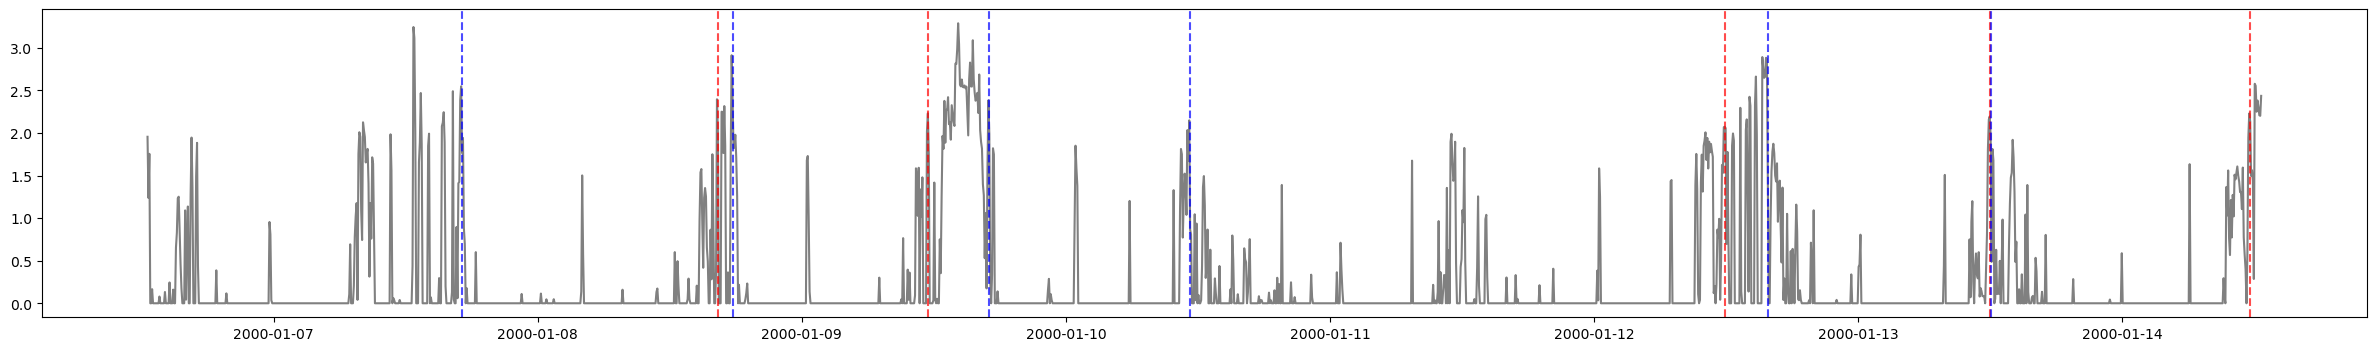

In [40]:
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[232]}_5min.parquet")
t0 = time.time()
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()


# =============================================================================
# function start: Calculate lights on time
# =============================================================================
# To be function parameters
threshold = 100
sustain_minutes = 10

# Set up data
df = df.sort_values("timestamp").copy()
epoch_minutes = lm.get_sampling_interval_minutes(df)
sustain_epochs = int(sustain_minutes / epoch_minutes)

# Add a date column
df["date"] = df["timestamp"].dt.date


# Loop through each date
onset_timestamps = []
for date, day_df in df.groupby("date"):
    day_df = day_df.sort_values("timestamp")

    # Binary variable for being above threshold
    above = (day_df["mean_lux"] > threshold).astype(int)
    
    rolling = above.rolling(sustain_epochs).sum()
    
    idx = rolling[rolling == sustain_epochs].index
    
    if len(idx) > 0:
        onset_time = day_df.loc[idx[0], "timestamp"]
        onset_timestamps.append(onset_time)

# Remove the first onset time because this reflects device setup
onset_timestamps = onset_timestamps[1:]

mean_onset_minutes = np.mean([
    t.hour * 60 + t.minute + t.second / 60
    for t in onset_timestamps
])
# function end =============================================================================


# =============================================================================
# function start: Calculate lights off time
# =============================================================================
threshold = 100
sustain_minutes = 30

df = df.sort_values("timestamp").copy()
epoch_minutes = lm.get_sampling_interval_minutes(df)
sustain_epochs = int(sustain_minutes / epoch_minutes)

df["date"] = df["timestamp"].dt.date

offset_times = []
offset_timestamps = []

for date, day_df in df.groupby("date"):
    day_df = day_df.sort_values("timestamp").reset_index(drop=True)
    
    below = (day_df["mean_lux"] < threshold).astype(int)
    above = (day_df["mean_lux"] >= threshold).astype(int)
    
    # Find transitions from light to dark
    transitions = (above.shift(1) == 1) & (below == 1)
    
    candidate_idxs = np.where(transitions)[0][::-1]
    
    for idx in candidate_idxs:
        # Check if sustained darkness follows
        end_idx = idx + sustain_epochs
        
        if end_idx < len(day_df):
            if below.iloc[idx:end_idx].sum() == sustain_epochs:
                offset_time = day_df.loc[idx, "timestamp"]
                
                minutes_since_midnight = (
                    offset_time.hour * 60 +
                    offset_time.minute +
                    offset_time.second / 60
                )
                
                offset_times.append(minutes_since_midnight)
                offset_timestamps.append(offset_time)
                
                break  # Only take first valid transition

# function end =============================================================================





# Plot the LUX curve and lights on and off times for visual validation
fig, ax = plt.subplots(figsize=(30,4))
ax.plot(df["timestamp"], np.log10(df["mean_lux"]+1), color="grey")
#ax.set_ylim(0, 500)


for onset in onset_timestamps:
    ax.axvline(onset, color="red", linestyle="--", alpha=0.7)

for offset in offset_timestamps:
    ax.axvline(offset, color="blue", linestyle="--", alpha=0.7)

In [35]:
def detect_photoperiod(df, threshold=100, smooth_minutes=60):

    df = df.sort_values("timestamp").copy()

    epoch_minutes = lm.get_sampling_interval_minutes(df)
    smooth_epochs = int(smooth_minutes / epoch_minutes)

    # Smooth lux
    df["lux_smooth"] = df["mean_lux"].rolling(
        smooth_epochs,
        center=True,
        min_periods=1
    ).median()

    # Binary light
    light = df["lux_smooth"] > threshold

    segments = []
    start_idx = None

    for i in range(len(light)):

        if light.iloc[i] and start_idx is None:
            start_idx = i

        elif not light.iloc[i] and start_idx is not None:
            segments.append((start_idx, i-1))
            start_idx = None

    if start_idx is not None:
        segments.append((start_idx, len(light)-1))

    if len(segments) == 0:
        return None

    # Find longest light segment
    durations = [
        (end-start+1)*epoch_minutes for start,end in segments
    ]

    longest_idx = np.argmax(durations)
    start,end = segments[longest_idx]

    onset_ts = df.loc[start,"timestamp"]
    offset_ts = df.loc[end,"timestamp"]

    onset_minutes = onset_ts.hour*60 + onset_ts.minute + onset_ts.second/60
    offset_minutes = offset_ts.hour*60 + offset_ts.minute + offset_ts.second/60

    return {
        "onset_timestamp": onset_ts,
        "offset_timestamp": offset_ts,
        "onset_minutes": onset_minutes,
        "offset_minutes": offset_minutes
    }

detect_photoperiod(df)

{'onset_timestamp': Timestamp('2000-01-06 16:22:30+0000', tz='UTC'),
 'offset_timestamp': Timestamp('2000-01-06 20:02:30+0000', tz='UTC'),
 'onset_minutes': 982.5,
 'offset_minutes': 1202.5}

In [33]:
df

,timestamp,mean_lux,date
0,2000-01-06 12:32:30+00:00,0.000000,2000-01-06
1,2000-01-06 12:37:30+00:00,0.000000,2000-01-06
2,2000-01-06 12:42:30+00:00,0.000000,2000-01-06
3,2000-01-06 12:47:30+00:00,1.013333,2000-01-06
4,2000-01-06 12:52:30+00:00,6.423333,2000-01-06
...,...,...,...
2301,2000-01-14 12:17:30+00:00,0.000000,2000-01-14
2302,2000-01-14 12:22:30+00:00,0.000000,2000-01-14
2303,2000-01-14 12:27:30+00:00,0.000000,2000-01-14
2304,2000-01-14 12:32:30+00:00,0.000000,2000-01-14
